In [1]:
import torch
import os
from pathlib import Path
import logging
import numpy as np
import time

# --- Add project root to sys.path ---
BASE_DIR = Path.cwd().parent.parent.parent
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_gnn"
ALL_DIR = DATA_DIR / "all"
RAW_DATA_DIR = BASE_DIR / "data" / "data_raw"
CACHE_DIR = BASE_DIR / "data" / "data_gnn"/ "cache"
# ------------------------------------

print(f"BASE_DIR: {BASE_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"ALL_DIR: {ALL_DIR}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")

os.chdir(BASE_DIR)
from src.graph_modelling.models.spatialonlygnn import SpatialOnlyGCN
from src.graph_modelling.models.temporalonlygnn import SimpleChebGRU
from src.graph_modelling.datasets.no2_dataset import NO2DatasetLoader
from src.graph_modelling.training.train_utils import train_model_index, evaluate_index
from src.graph_modelling.visualization.visualization import (
    plot_training_history,
    plot_predictions,
    set_base_dir,
)
import inspect
import matplotlib.pyplot as plt
import seaborn as sns
import json

# A logger for this file
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)

N_HOURS_IN = 72
N_HOURS_OUT = 24
N_HOURS_PRED = 24
OFFSET = 49

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: /home/nick/bachelor-project/third-copy
MODEL_PATH: /home/nick/bachelor-project/third-copy/results/models
DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn
ALL_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn/all
RAW_DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_raw
Using device: cuda


# Spatial Loss

In [2]:
with open("comparison_results/training_logs/spatial_logs.json") as f:
    spatial_logs = json.load(f)

spatial_logs

{'train_loss': [0.2067621687525197,
  0.1934451460838318,
  0.18225129066329254,
  0.1726885775202199,
  0.16109481414681986,
  0.1516482314389003,
  0.1435958841129353,
  0.13537536914411344,
  0.1265465960298714,
  0.12019901016825124,
  0.11321585468555752,
  0.10610593874987803,
  0.10118629489290087,
  0.0953550279924744,
  0.09001399459023225,
  0.08597146327558317,
  0.08183307102636288,
  0.07791668686427568,
  0.07438448336171477,
  0.07119982571978319,
  0.06828875476984601,
  0.06567427535590373,
  0.06358474032267143,
  0.06168911439415656,
  0.05918131454994804,
  0.05790308794300807,
  0.05622262860599317,
  0.05474796567700411,
  0.05358956332661604,
  0.052183710626865686,
  0.05107586742623856,
  0.04988188355376846,
  0.049532037130311915,
  0.04812485136483845,
  0.04716984770799938,
  0.046832647762800515,
  0.04641874806073151,
  0.04574114280311685,
  0.044893239134628525,
  0.04441194020603832,
  0.04420817663010798,
  0.0433784980130823,
  0.043246720378336156,


In [3]:
# print training losses from logs
spatial_logs_train = spatial_logs["train_loss"]
spatial_logs_val = spatial_logs["val_loss"]
print(spatial_logs_train)
print(spatial_logs_val)

[0.2067621687525197, 0.1934451460838318, 0.18225129066329254, 0.1726885775202199, 0.16109481414681986, 0.1516482314389003, 0.1435958841129353, 0.13537536914411344, 0.1265465960298714, 0.12019901016825124, 0.11321585468555752, 0.10610593874987803, 0.10118629489290087, 0.0953550279924744, 0.09001399459023225, 0.08597146327558317, 0.08183307102636288, 0.07791668686427568, 0.07438448336171477, 0.07119982571978319, 0.06828875476984601, 0.06567427535590373, 0.06358474032267143, 0.06168911439415656, 0.05918131454994804, 0.05790308794300807, 0.05622262860599317, 0.05474796567700411, 0.05358956332661604, 0.052183710626865686, 0.05107586742623856, 0.04988188355376846, 0.049532037130311915, 0.04812485136483845, 0.04716984770799938, 0.046832647762800515, 0.04641874806073151, 0.04574114280311685, 0.044893239134628525, 0.04441194020603832, 0.04420817663010798, 0.0433784980130823, 0.043246720378336156, 0.04250196671407474, 0.04252648333969869, 0.04198222906377755, 0.0412715104849715, 0.04119515183724

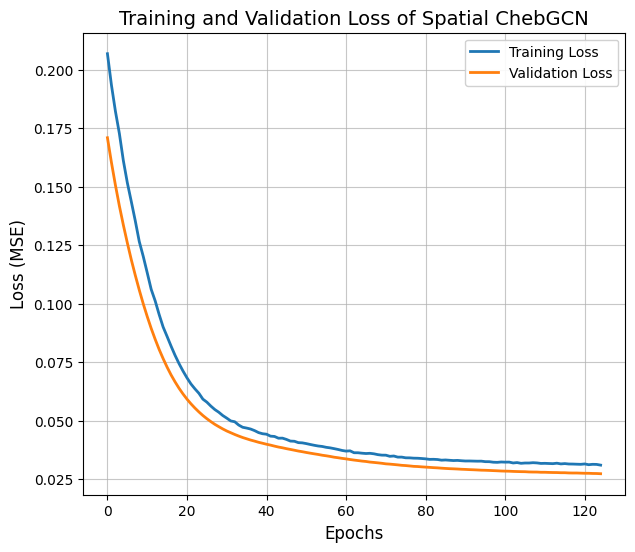

<module 'matplotlib.pyplot' from '/home/nick/bachelor-project/third-copy/.env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [39]:
def plot_training_validation_loss(train_loss, val_loss, title="Model Training and Validation Loss", 
                                 figsize=(7, 6), save_path=None):
    plt.figure(figsize=figsize)
    
    # Use consistent colors for train/val
    train_color = sns.color_palette("tab10")[0]
    val_color = sns.color_palette("tab10")[1]
    
    # Plot training and validation loss
    plt.plot(train_loss, label="Training Loss", 
             color=train_color, linestyle='-', linewidth=2)
    plt.plot(val_loss, label="Validation Loss", 
             color=val_color, linestyle='-', linewidth=2)
        
    plt.title(title, fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss (MSE)", fontsize=12)
    plt.grid(True, linestyle='-', alpha=0.7)
    
    
    # Create a cleaner legend with better spacing
    plt.legend(fontsize=10, frameon=True, fancybox=True, 
               framealpha=0.9, loc='upper right')
    
    # Add a bit more margin at the bottom to prevent x-label cutoff
    # plt.tight_layout(pad=2.0)
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        
    plt.show()
    
    return plt

plot_training_validation_loss(
    spatial_logs["train_loss"][:125], 
    spatial_logs["val_loss"][:125],
    title="Training and Validation Loss of Spatial ChebGCN",
)

# ChebGru loss

In [40]:
with open("comparison_results/training_logs/chebgru_logs.json") as f:
    chebgru_logs = json.load(f)

chebgru_logs

{'train_loss': [0.18757883420116023,
  0.17491772770881653,
  0.16347279576094528,
  0.15056011335630165,
  0.13780312200910166,
  0.12396132593092166,
  0.10887711514767848,
  0.09391068598549616,
  0.08107781165132397,
  0.06969925290659855,
  0.06065395396006735,
  0.05461271313068114,
  0.05053835322982386,
  0.04727255366742611,
  0.044780108979658076,
  0.04310452457713453,
  0.04167301938133804,
  0.039851067097563496,
  0.03877657627392756,
  0.03761197097207371,
  0.03612127439364007,
  0.034684903968713786,
  0.033788148166709824,
  0.03241691150163349,
  0.03101549714215492,
  0.030058420998485463,
  0.028942186336376165,
  0.027877364503709895,
  0.02669689358261071,
  0.026212854482429594,
  0.025646963646929515,
  0.02529829162123956,
  0.024770379458603105,
  0.0244256337418368,
  0.023933386724246174,
  0.02356951649447805,
  0.023205391131341457,
  0.023048895876854658,
  0.022767224153013604,
  0.022488364165550785,
  0.021928384409923302,
  0.02188742758804246,
  0.0

In [46]:
# trim number of epcohs
chebgru_logs["train_loss"] = chebgru_logs["train_loss"][:120]
chebgru_logs["val_loss"] = chebgru_logs["val_loss"][:120]

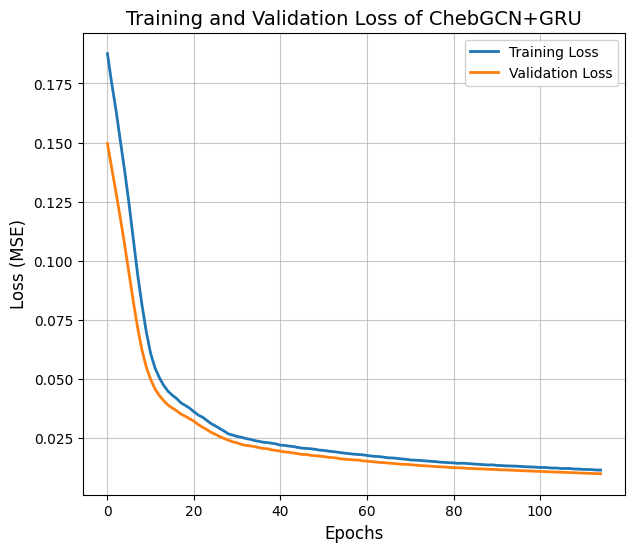

<module 'matplotlib.pyplot' from '/home/nick/bachelor-project/third-copy/.env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [47]:
plot_training_validation_loss(
    chebgru_logs["train_loss"], 
    chebgru_logs["val_loss"],
    title="Training and Validation Loss of ChebGCN+GRU",
)

# ASTGCN Loss

In [48]:
with open("comparison_results/training_logs/astgcn_logs.json") as f:
    astgn_logs = json.load(f)

astgn_logs

{'train_loss': [0.07505170095829586,
  0.05325019286063157,
  0.05024902424529979,
  0.049510188302711436,
  0.05072027224263078,
  0.048809226994451727,
  0.04777941823397812,
  0.0476543362693567,
  0.04519760108699924,
  0.04231507747777199,
  0.040492885451959934,
  0.037515113816449515,
  0.037073379823643914,
  0.036220049926717034,
  0.03323976822981709,
  0.030914819358210815,
  0.028315697502540916,
  0.02783801445835515,
  0.025149570336859477,
  0.02336182430582611,
  0.022006571145826263,
  0.0209035391576196,
  0.019346094028534072,
  0.018897222575584526,
  0.0174614538830754,
  0.016240932856147226,
  0.014919044793044267,
  0.014352918087847923,
  0.012973920001011146,
  0.012443193553113624,
  0.011471958806444155,
  0.010830298164173177,
  0.010461290317930673,
  0.009832202138281182,
  0.009305415944637437,
  0.008803922915831208,
  0.008622868084593824,
  0.008210152657212396,
  0.007916627194438326,
  0.007428431834437345,
  0.007211924653108183,
  0.00687549945800

In [49]:
# trim number of epochs
astgn_logs["train_loss"] = astgn_logs["train_loss"][:115]
astgn_logs["val_loss"] = astgn_logs["val_loss"][:115]

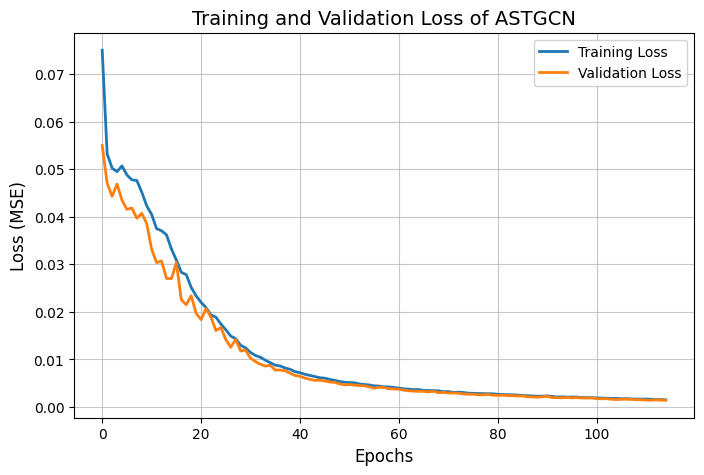

<module 'matplotlib.pyplot' from '/home/nick/bachelor-project/third-copy/.env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [50]:

# Plot with exponential decay curves
plot_training_validation_loss(
    astgn_logs["train_loss"], 
    astgn_logs["val_loss"],
    title="Training and Validation Loss of ASTGCN",
    figsize=(8, 5),
)